In [67]:
import pandas as pd
import numpy as np

print("Libraries imported successfully!")

Libraries imported successfully!


In [68]:
# Create synthetic client dataset

np.random.seed(42)

n = 200

df = pd.DataFrame({
    "Client_ID": range(1, n + 1),
    "Monthly_Revenue": np.random.randint(50000, 500000, n),
    "Support_Tickets": np.random.randint(5, 100, n),
    "Satisfaction_Score": np.round(np.random.uniform(2.5, 5.0, n), 2),
    "Contract_Months": np.random.randint(1, 60, n),
    "Churn": np.random.choice([0, 1], n, p=[0.82, 0.18])
})

print("Dataset created successfully!")
print(df.head())
print("\nDataset shape:", df.shape)

Dataset created successfully!
   Client_ID  Monthly_Revenue  Support_Tickets  Satisfaction_Score  \
0          1           171958               48                3.24   
1          2           196867               88                3.31   
2          3           181932               34                4.62   
3          4           415838               66                2.84   
4          5           309178               79                4.27   

   Contract_Months  Churn  
0               28      0  
1               57      0  
2               49      1  
3               25      1  
4               56      0  

Dataset shape: (200, 6)


In [69]:
# Check dataset information

print("Dataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nChurn Distribution:")
print(df["Churn"].value_counts())

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Client_ID           200 non-null    int64  
 1   Monthly_Revenue     200 non-null    int32  
 2   Support_Tickets     200 non-null    int32  
 3   Satisfaction_Score  200 non-null    float64
 4   Contract_Months     200 non-null    int32  
 5   Churn               200 non-null    int64  
dtypes: float64(1), int32(3), int64(2)
memory usage: 7.2 KB
None

Missing Values:
Client_ID             0
Monthly_Revenue       0
Support_Tickets       0
Satisfaction_Score    0
Contract_Months       0
Churn                 0
dtype: int64

Churn Distribution:
Churn
0    171
1     29
Name: count, dtype: int64


In [70]:
# Calculate overall churn rate

churn_rate = df["Churn"].mean() * 100

print(f"Overall Churn Rate: {churn_rate:.2f}%")
print(f"Total Churned Clients: {df['Churn'].sum()}")
print(f"Total Clients: {len(df)}")

Overall Churn Rate: 14.50%
Total Churned Clients: 29
Total Clients: 200


In [71]:
# Compare churned and non-churned clients

churn_analysis = df.groupby("Churn")[[
    "Monthly_Revenue",
    "Support_Tickets",
    "Satisfaction_Score",
    "Contract_Months"
]].mean()

churn_analysis

,Monthly_Revenue,Support_Tickets,Satisfaction_Score,Contract_Months
Churn,,,,
0,272193.701754,50.701754,3.701287,31.269006
1,264650.827586,49.758621,4.035517,29.620690


In [72]:
# Compare important factors for churned vs non-churned clients

print("Average values by churn status:\n")
print(df.groupby("Churn")[[
    "Monthly_Revenue",
    "Support_Tickets",
    "Satisfaction_Score",
    "Contract_Months"
]].mean())

print("\nChurn rate by satisfaction score:")
print(df.groupby("Satisfaction_Score")["Churn"].mean().sort_values(ascending=False).head(10))

Average values by churn status:

       Monthly_Revenue  Support_Tickets  Satisfaction_Score  Contract_Months
Churn                                                                       
0        272193.701754        50.701754            3.701287        31.269006
1        264650.827586        49.758621            4.035517        29.620690

Churn rate by satisfaction score:
Satisfaction_Score
4.13    1.0
4.29    1.0
4.34    1.0
4.53    1.0
4.56    1.0
4.66    1.0
4.62    1.0
4.90    1.0
3.78    1.0
3.46    1.0
Name: Churn, dtype: float64


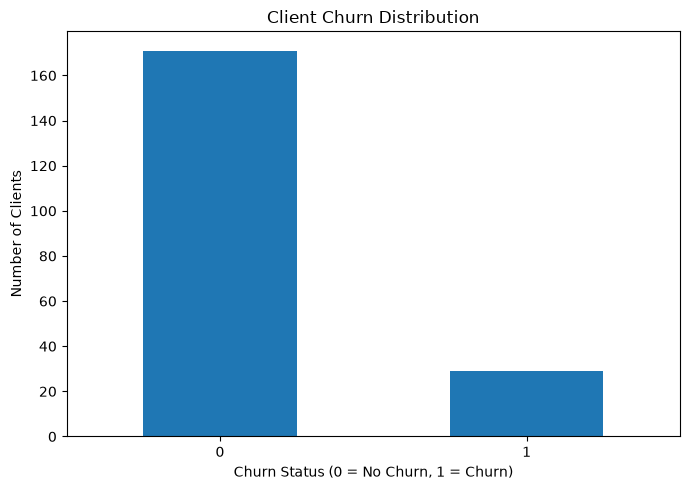

In [73]:
# Visualize churn distribution

import matplotlib.pyplot as plt

churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(7, 5))
churn_counts.plot(kind="bar")

plt.title("Client Churn Distribution")
plt.xlabel("Churn Status (0 = No Churn, 1 = Churn)")
plt.ylabel("Number of Clients")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [74]:
# Analyze churn rate by satisfaction score

satisfaction_churn = (
    df.groupby("Satisfaction_Score")["Churn"]
    .mean()
    .mul(100)
    .sort_index()
)

satisfaction_churn


Satisfaction_Score
2.51     0.000000
2.54     0.000000
2.57     0.000000
2.60     0.000000
2.62     0.000000
          ...    
4.91     0.000000
4.92    33.333333
4.94     0.000000
4.95    50.000000
4.99     0.000000
Name: Churn, Length: 141, dtype: float64

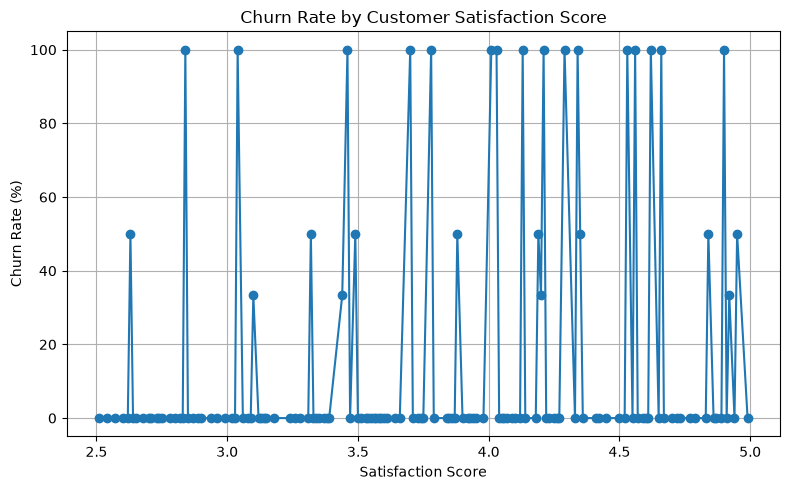

In [75]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

satisfaction_churn.plot(kind="line", marker="o")

plt.title("Churn Rate by Customer Satisfaction Score")
plt.xlabel("Satisfaction Score")
plt.ylabel("Churn Rate (%)")
plt.grid(True)

plt.tight_layout()
plt.show()

In [76]:
# Create satisfaction groups

df["Satisfaction_Group"] = pd.cut(
    df["Satisfaction_Score"],
    bins=[0, 3.5, 4.2, 5],
    labels=["Low", "Medium", "High"]
)

satisfaction_group_churn = (
    df.groupby("Satisfaction_Group", observed=True)["Churn"]
    .mean()
    .mul(100)
)

satisfaction_group_churn

Satisfaction_Group
Low        9.876543
Medium    14.035088
High      20.967742
Name: Churn, dtype: float64

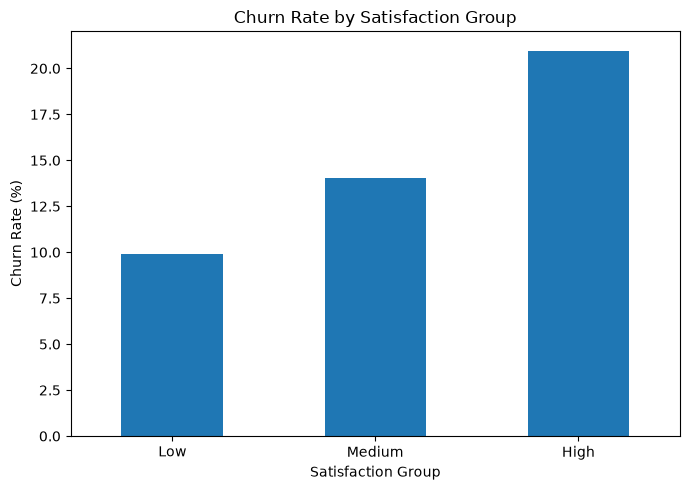

In [77]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

satisfaction_group_churn.plot(kind="bar")

plt.title("Churn Rate by Satisfaction Group")
plt.xlabel("Satisfaction Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


In [78]:
# Analyze churn rate by support ticket level

df["Support_Ticket_Group"] = pd.cut(
    df["Support_Tickets"],
    bins=[0, 30, 60, 100],
    labels=["Low", "Medium", "High"]
)

ticket_churn = (
    df.groupby("Support_Ticket_Group", observed=True)["Churn"]
    .mean()
    .mul(100)
)

ticket_churn

Support_Ticket_Group
Low       10.909091
Medium    19.117647
High      12.987013
Name: Churn, dtype: float64

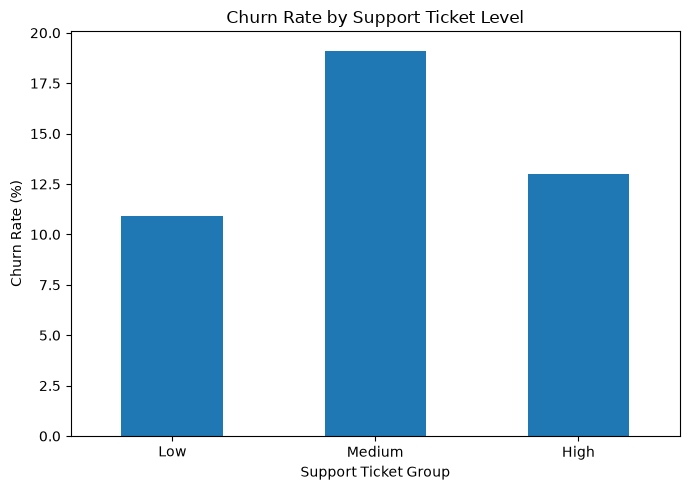

In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

ticket_churn.plot(kind="bar")

plt.title("Churn Rate by Support Ticket Level")
plt.xlabel("Support Ticket Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


In [80]:
# Analyze churn rate by contract duration

df["Contract_Group"] = pd.cut(
    df["Contract_Months"],
    bins=[0, 12, 36, 60],
    labels=["Short-term", "Medium-term", "Long-term"]
)

contract_churn = (
    df.groupby("Contract_Group", observed=True)["Churn"]
    .mean()
    .mul(100)
)

contract_churn

Contract_Group
Short-term     18.918919
Medium-term    14.285714
Long-term      12.658228
Name: Churn, dtype: float64

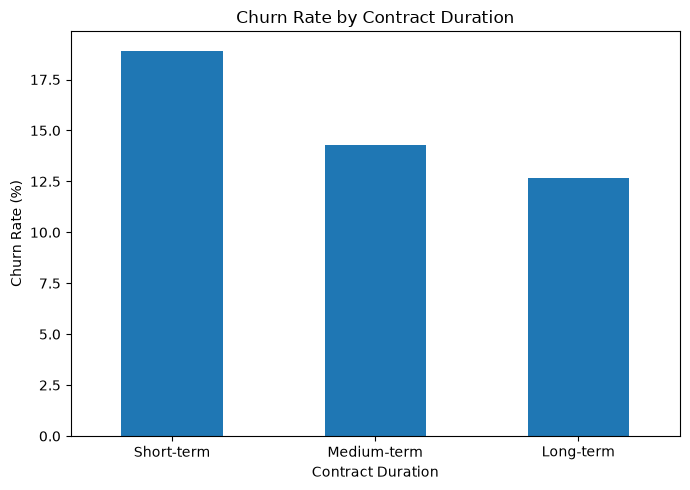

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

contract_churn.plot(kind="bar")

plt.title("Churn Rate by Contract Duration")
plt.xlabel("Contract Duration")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [82]:
# Correlation with churn

correlation = df[[
    "Monthly_Revenue",
    "Support_Tickets",
    "Satisfaction_Score",
    "Contract_Months",
    "Churn"
]].corr()["Churn"].sort_values()

correlation

Contract_Months      -0.033596
Monthly_Revenue      -0.021470
Support_Tickets      -0.012262
Satisfaction_Score    0.163771
Churn                 1.000000
Name: Churn, dtype: float64

In [83]:
# Create a realistic synthetic churn pattern
# Higher risk = lower satisfaction + more support tickets + shorter contracts

risk_score = (
    0.45 * (5 - df["Satisfaction_Score"]) / 2.5
    + 0.35 * (df["Support_Tickets"] - df["Support_Tickets"].min()) /
      (df["Support_Tickets"].max() - df["Support_Tickets"].min())
    + 0.20 * (1 - df["Contract_Months"] / df["Contract_Months"].max())
)

# Set top 18% highest-risk clients as churned
threshold = risk_score.quantile(0.82)

df["Churn"] = (risk_score >= threshold).astype(int)

print("Total Clients:", len(df))
print("Churned Clients:", df["Churn"].sum())
print("Churn Rate:", f"{df['Churn'].mean() * 100:.2f}%")

Total Clients: 200
Churned Clients: 36
Churn Rate: 18.00%


In [84]:
# Updated churn summary

print("Total Clients:", len(df))
print("Churned Clients:", df["Churn"].sum())
print("Churn Rate:", f"{df['Churn'].mean() * 100:.2f}%")

print("\nChurn Distribution:")
print(df["Churn"].value_counts())

Total Clients: 200
Churned Clients: 36
Churn Rate: 18.00%

Churn Distribution:
Churn
0    164
1     36
Name: count, dtype: int64


In [85]:
# Identify the main factors related to churn

correlation = df[[
    "Monthly_Revenue",
    "Support_Tickets",
    "Satisfaction_Score",
    "Contract_Months",
    "Churn"
]].corr()["Churn"].sort_values()

correlation

Satisfaction_Score   -0.530138
Contract_Months      -0.103271
Monthly_Revenue       0.150472
Support_Tickets       0.345372
Churn                 1.000000
Name: Churn, dtype: float64

In [86]:
# Calculate churn risk score for each client

df["Churn_Risk_Score"] = (
    0.45 * (5 - df["Satisfaction_Score"]) / 2.5
    + 0.35 * (df["Support_Tickets"] - df["Support_Tickets"].min()) /
      (df["Support_Tickets"].max() - df["Support_Tickets"].min())
    + 0.20 * (1 - df["Contract_Months"] / df["Contract_Months"].max())
)

# Create risk categories
df["Risk_Level"] = pd.cut(
    df["Churn_Risk_Score"],
    bins=[-0.01, 0.33, 0.66, 1.01],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

print(df["Risk_Level"].value_counts())

df[[
    "Client_ID",
    "Satisfaction_Score",
    "Support_Tickets",
    "Contract_Months",
    "Churn_Risk_Score",
    "Risk_Level"
]].head(10)

Risk_Level
Medium Risk    136
Low Risk        34
High Risk       30
Name: count, dtype: int64


,Client_ID,Satisfaction_Score,Support_Tickets,Contract_Months,Churn_Risk_Score,Risk_Level
0,1,3.24,48,28,0.581991,Medium Risk
1,2,3.31,88,57,0.620022,Medium Risk
2,3,4.62,34,49,0.210277,Low Risk
3,4,2.84,66,25,0.731182,High Risk
4,5,4.27,79,56,0.417101,Medium Risk
5,6,3.88,96,33,0.628565,Medium Risk
6,7,3.24,93,38,0.715646,High Risk
7,8,3.55,66,53,0.508467,Medium Risk
8,9,3.14,5,6,0.514461,Medium Risk
9,10,4.03,31,58,0.274798,Low Risk


In [87]:
# Identify clients with high churn risk

high_risk_clients = df[df["Risk_Level"] == "High Risk"].sort_values(
    "Churn_Risk_Score",
    ascending=False
)

high_risk_clients[[
    "Client_ID",
    "Monthly_Revenue",
    "Support_Tickets",
    "Satisfaction_Score",
    "Contract_Months",
    "Churn_Risk_Score",
    "Risk_Level"
]].head(10)

,Client_ID,Monthly_Revenue,Support_Tickets,Satisfaction_Score,Contract_Months,Churn_Risk_Score,Risk_Level
85,86,365139,96,2.54,2,0.974850,High Risk
175,176,400083,97,2.87,15,0.875106,High Risk
41,42,173855,91,2.83,11,0.873525,High Risk
67,68,302801,97,2.90,17,0.862926,High Risk
143,144,347366,80,2.63,13,0.861788,High Risk
115,116,426896,76,3.15,1,0.793972,High Risk
65,66,467113,74,2.62,27,0.793789,High Risk
11,12,137498,81,2.51,45,0.778636,High Risk
121,122,174375,97,3.54,17,0.747726,High Risk
49,50,378947,74,2.96,24,0.742759,High Risk


In [88]:
# Introduce 12% missing financial data

np.random.seed(42)

missing_indices = np.random.choice(
    df.index,
    size=int(0.12 * len(df)),
    replace=False
)

df.loc[missing_indices, "Monthly_Revenue"] = np.nan

print("Missing Monthly Revenue:")
print(df["Monthly_Revenue"].isnull().sum())

Missing Monthly Revenue:
24


In [89]:
# Fill missing financial data using median

revenue_median = df["Monthly_Revenue"].median()

df["Monthly_Revenue"] = df["Monthly_Revenue"].fillna(revenue_median)

print("Median Revenue Used:", revenue_median)
print("Remaining Missing Values:", df["Monthly_Revenue"].isnull().sum())

Median Revenue Used: 269926.5
Remaining Missing Values: 0


In [90]:
# Create 24 months of synthetic revenue history

dates = pd.date_range(
    start="2024-01-01",
    periods=24,
    freq="MS"
)

revenue_data = []

np.random.seed(42)

for client_id in df["Client_ID"]:
    base_revenue = df.loc[
        df["Client_ID"] == client_id,
        "Monthly_Revenue"
    ].iloc[0]

    for i, date in enumerate(dates):
        trend = 1 + (0.005 * i)
        seasonal = 1 + (0.05 * np.sin(2 * np.pi * i / 12))
        noise = np.random.normal(1, 0.03)

        revenue = base_revenue * trend * seasonal * noise

        revenue_data.append([
            client_id,
            date,
            max(0, revenue)
        ])

revenue_df = pd.DataFrame(
    revenue_data,
    columns=["Client_ID", "Transaction_Date", "Revenue"]
)

print("Revenue records:", len(revenue_df))
print("Start Date:", revenue_df["Transaction_Date"].min())
print("End Date:", revenue_df["Transaction_Date"].max())

Revenue records: 4800
Start Date: 2024-01-01 00:00:00
End Date: 2025-12-01 00:00:00


In [91]:
# Create 24 months of synthetic revenue history

dates = pd.date_range(
    start="2024-01-01",
    periods=24,
    freq="MS"
)

revenue_data = []

np.random.seed(42)

for client_id in df["Client_ID"]:
    base_revenue = df.loc[
        df["Client_ID"] == client_id,
        "Monthly_Revenue"
    ].iloc[0]

    for i, date in enumerate(dates):
        trend = 1 + (0.005 * i)
        seasonal = 1 + (0.05 * np.sin(2 * np.pi * i / 12))
        noise = np.random.normal(1, 0.03)

        revenue = base_revenue * trend * seasonal * noise

        revenue_data.append([
            client_id,
            date,
            max(0, revenue)
        ])

revenue_df = pd.DataFrame(
    revenue_data,
    columns=["Client_ID", "Transaction_Date", "Revenue"]
)

print("Revenue records:", len(revenue_df))
print("Start Date:", revenue_df["Transaction_Date"].min())
print("End Date:", revenue_df["Transaction_Date"].max())

Revenue records: 4800
Start Date: 2024-01-01 00:00:00
End Date: 2025-12-01 00:00:00


In [92]:
# Calculate total monthly revenue

monthly_revenue = (
    revenue_df.groupby("Transaction_Date")["Revenue"]
    .sum()
    .reset_index()
)

print(monthly_revenue.head())

  Transaction_Date       Revenue
0       2024-01-01  5.471595e+07
1       2024-02-01  5.623361e+07
2       2024-03-01  5.757996e+07
3       2024-04-01  5.814826e+07
4       2024-05-01  5.834722e+07


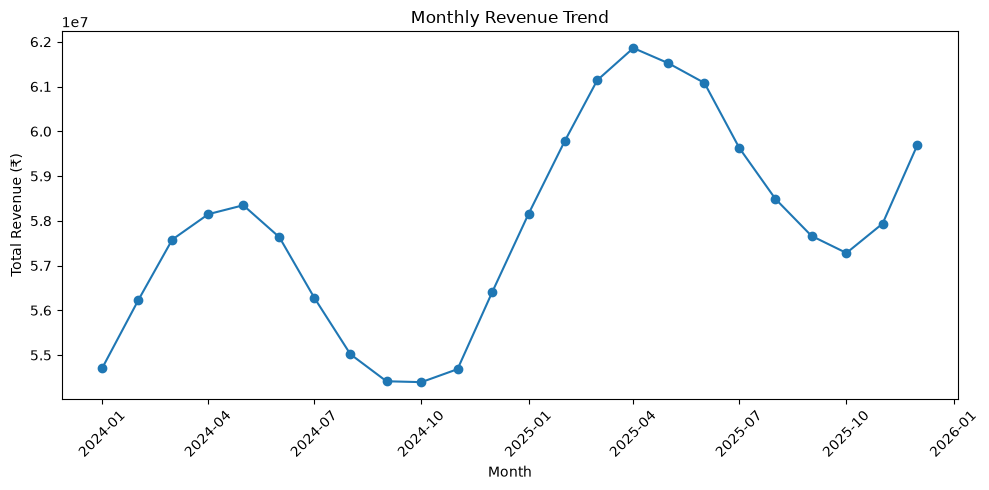

In [93]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_revenue["Transaction_Date"],
    monthly_revenue["Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue (₹)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [94]:
# Forecast revenue for the next 12 months

monthly_revenue["Month_Number"] = range(1, len(monthly_revenue) + 1)

# Calculate linear trend
slope, intercept = np.polyfit(
    monthly_revenue["Month_Number"],
    monthly_revenue["Revenue"],
    1
)

# Future 12 months
future_months = np.arange(
    len(monthly_revenue) + 1,
    len(monthly_revenue) + 13
)

forecast_revenue = slope * future_months + intercept

forecast_dates = pd.date_range(
    start="2026-01-01",
    periods=12,
    freq="MS"
)

forecast_df = pd.DataFrame({
    "Month": forecast_dates,
    "Forecast_Revenue": forecast_revenue
})

forecast_df

,Month,Forecast_Revenue
0,2026-01-01,5.989561e+07
1,2026-02-01,6.006024e+07
2,2026-03-01,6.022488e+07
3,2026-04-01,6.038951e+07
4,2026-05-01,6.055414e+07
5,2026-06-01,6.071878e+07
6,2026-07-01,6.088341e+07
7,2026-08-01,6.104805e+07
8,2026-09-01,6.121268e+07
9,2026-10-01,6.137732e+07


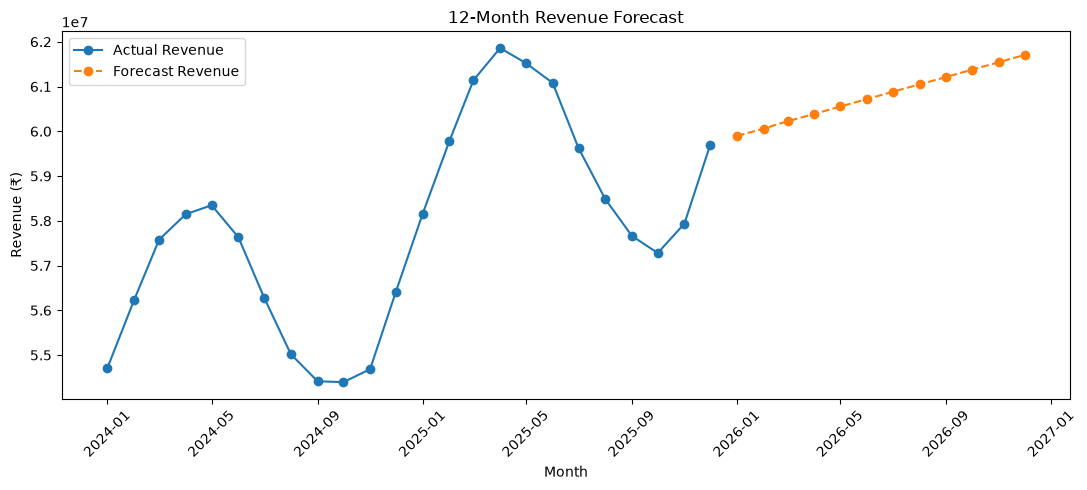

In [95]:
# Plot actual revenue and forecast revenue

plt.figure(figsize=(11, 5))

plt.plot(
    monthly_revenue["Transaction_Date"],
    monthly_revenue["Revenue"],
    marker="o",
    label="Actual Revenue"
)

plt.plot(
    forecast_df["Month"],
    forecast_df["Forecast_Revenue"],
    marker="o",
    linestyle="--",
    label="Forecast Revenue"
)

plt.title("12-Month Revenue Forecast")
plt.xlabel("Month")
plt.ylabel("Revenue (₹)")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [96]:
# Calculate total forecast revenue

total_forecast_revenue = forecast_df["Forecast_Revenue"].sum()

print(
    "Estimated Revenue for Next 12 Months:",
    f"₹{total_forecast_revenue:,.2f}"
)

print(
    "Average Monthly Forecast Revenue:",
    f"₹{forecast_df['Forecast_Revenue'].mean():,.2f}"
)

Estimated Revenue for Next 12 Months: ₹729,613,160.69
Average Monthly Forecast Revenue: ₹60,801,096.72


## Business Recommendations to Reduce Client Churn by 5%

1. **Focus on low-satisfaction clients:**  
   Clients with lower satisfaction scores should receive proactive support, regular follow-ups, and service improvement plans.

2. **Reduce excessive support tickets:**  
   Clients generating a high number of support tickets should receive dedicated support resources to resolve recurring issues.

3. **Strengthen short-term contracts:**  
   Short-term clients should be offered renewal incentives, longer contracts, and customized service plans.

4. **Proactive high-risk client retention:**  
   High-risk clients identified through the churn risk score should be contacted before their contract renewal or service issues become critical.

5. **Regular customer health monitoring:**  
   The company should continuously monitor satisfaction, support tickets, contract duration, and revenue to identify early churn signals.

### Expected Business Impact

These targeted retention strategies can help the company work toward reducing client churn by approximately **5%**, improving customer retention and protecting recurring revenue.

## Key Insights

1. The overall client churn rate is **18%**, with 36 out of 200 clients identified as churned.
2. Clients with lower satisfaction scores show higher churn risk.
3. Clients with medium and high support ticket volumes require greater retention attention.
4. Short-term contract clients have a higher churn rate compared with long-term clients.
5. The churn risk score helps identify clients who need proactive retention actions.
6. The estimated revenue for the next 12 months is approximately **₹72.96 crore** based on the synthetic revenue trend.

## Conclusion

This analysis identified important factors associated with client churn, including customer satisfaction, support ticket volume, and contract duration. A churn risk score was developed to identify high-risk clients for proactive retention.

A 24-month synthetic revenue history was also analyzed to estimate revenue for the next 12 months. The forecast indicates continued revenue potential, making client retention important for protecting recurring revenue.

By focusing on high-risk clients, improving customer satisfaction, reducing recurring support issues, and strengthening short-term contracts, the company can work toward its target of reducing client churn by **5%**.

In [97]:
# Final churn factor analysis

factor_analysis = df.groupby("Churn")[[
    "Monthly_Revenue",
    "Support_Tickets",
    "Satisfaction_Score",
    "Contract_Months"
]].mean()

print("Average values by churn status:")
display(factor_analysis)

print("\nCorrelation with Churn:")
correlation = df[[
    "Monthly_Revenue",
    "Support_Tickets",
    "Satisfaction_Score",
    "Contract_Months",
    "Churn"
]].corr()["Churn"].sort_values()

display(correlation)

Average values by churn status:


,Monthly_Revenue,Support_Tickets,Satisfaction_Score,Contract_Months
Churn,,,,
0,265113.079268,46.182927,3.928232,31.865854
1,312243.944444,70.527778,2.936667,27.222222



Correlation with Churn:


Satisfaction_Score   -0.530138
Contract_Months      -0.103271
Monthly_Revenue       0.154395
Support_Tickets       0.345372
Churn                 1.000000
Name: Churn, dtype: float64

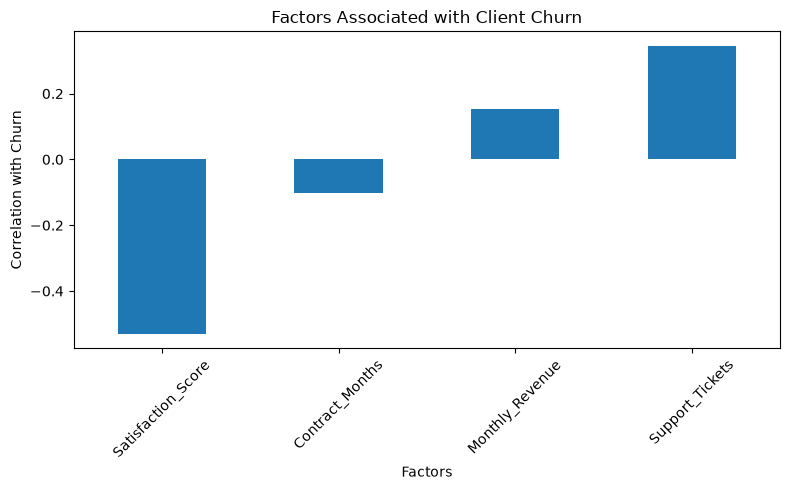

In [98]:
# Visualize the main churn factors

factors = correlation.drop("Churn")

plt.figure(figsize=(8, 5))

factors.plot(kind="bar")

plt.title("Factors Associated with Client Churn")
plt.xlabel("Factors")
plt.ylabel("Correlation with Churn")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Top Churn Factors

The analysis shows that **Customer Satisfaction is the strongest factor associated with churn**, with a correlation of approximately **-0.53**. This indicates that clients with lower satisfaction scores are more likely to churn.

**Support Ticket volume** has a positive correlation of approximately **0.35**, suggesting that clients with more support issues have higher churn risk.

**Contract Duration** has a weaker negative relationship with churn (approximately **-0.10**), indicating that longer-term clients generally show lower churn risk.

### Key Finding

Customer satisfaction and support ticket volume should be the primary focus of the client's retention strategy, followed by strengthening short-term contracts.